In [ ]:
pip install yfinance

In [ ]:
import yfinance as yf
from datetime import datetime, timedelta

# 获取昨天的日期
end_date = datetime.today() - timedelta(days=1)
start_date = end_date - timedelta(days=365 * 3)

# 格式化为字符串形式（yfinance需要）
start_str = start_date.strftime('%Y-%m-%d')
end_str = end_date.strftime('%Y-%m-%d')

# 下载江西铜业的股票数据
ticker = "600362.SS"
data = yf.download(ticker, start=start_str, end=end_str)

# 保存为CSV文件
data.to_csv('recent_stock_prices.csv')
print(f"数据已保存到 recent_stock_prices.csv（从 {start_str} 到 {end_str}）")


/tmp/ipython-input-995683346.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_str, end=end_str)
[*********************100%***********************]  1 of 1 completed

数据已保存到 recent_stock_prices.csv（从 2022-08-01 到 2025-07-31）


In [ ]:
import pandas as pd

# 加载原始 CSV 文件
try:
    data = pd.read_csv('recent_stock_prices.csv')
    print("CSV 数据预览：")
    print(data.head())
except pd.errors.EmptyDataError:
    print("CSV 文件为空，请检查数据来源或重新下载。")
except FileNotFoundError:
    print("文件不存在，请确认文件路径是否正确。")

# 清理列名并删除前两行
data.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
data = data.iloc[2:]
data.reset_index(drop=True, inplace=True)

# 转换日期格式并处理缺失值
data['Date'] = pd.to_datetime(data['Date'])
data = data.dropna()

# 保存清洗后的数据
data.to_csv('cleaned_stock_prices.csv', index=False)
print("数据已清洗并保存到 cleaned_stock_prices.csv")


CSV 数据预览：
        Price               Close                High                 Low  \
0      Ticker           600362.SS           600362.SS           600362.SS   
1        Date                 NaN                 NaN                 NaN   
2  2022-08-01  15.538910865783691  15.658512706097396   15.37330939751753   
3  2022-08-02  15.124910354614258   15.36411230268417  14.885708406544348   
4  2022-08-03  14.996106147766113  15.272109167188505  14.977707350289885   

                 Open     Volume  
0           600362.SS  600362.SS  
1                 NaN        NaN  
2  15.520512067466704   10104497  
3   15.36411230268417   12337565  
4  15.042107528389801    9441707  
数据已清洗并保存到 cleaned_stock_prices.csv


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# 加载清洗后的数据
data = pd.read_csv('cleaned_stock_prices.csv')
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values(by='Date')

# 日期转换为数值型特征
data['Date_Ordinal'] = data['Date'].map(lambda x: x.toordinal())

# 提取特征列并进行标准化
features = ['Date_Ordinal', 'Open', 'High', 'Low', 'Close', 'Volume']
data = data[features]

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 加载清洗后的数据
data = pd.read_csv('cleaned_stock_prices.csv')

# 确保 Date 是 datetime 类型，并排序
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values(by='Date')

# 保留需要的特征列
features = ['Open', 'High', 'Low', 'Close', 'Volume']
data = data[features]

# 标准化处理
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)
# 打印前五行
print("清洗后数据的前五行：")
print(data.head())


清洗后数据的前五行：
        Open       High        Low      Close    Volume
0  15.520512  15.658513  15.373309  15.538911  10104497
1  15.364112  15.364112  14.885708  15.124910  12337565
2  15.042108  15.272109  14.977707  14.996106   9441707
3  15.060510  15.115710  14.839707  14.968509   6971199
4  14.996106  15.695311  14.986907  15.630911  17222210


/tmp/ipython-input-4188321185.py:25: UserWarning: Glyph 38543 (\N{CJK UNIFIED IDEOGRAPH-968F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4188321185.py:25: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4188321185.py:25: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4188321185.py:25: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4188321185.py:25: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38543 (\N{CJK UNIFIED IDEOGRAPH-968F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPyt

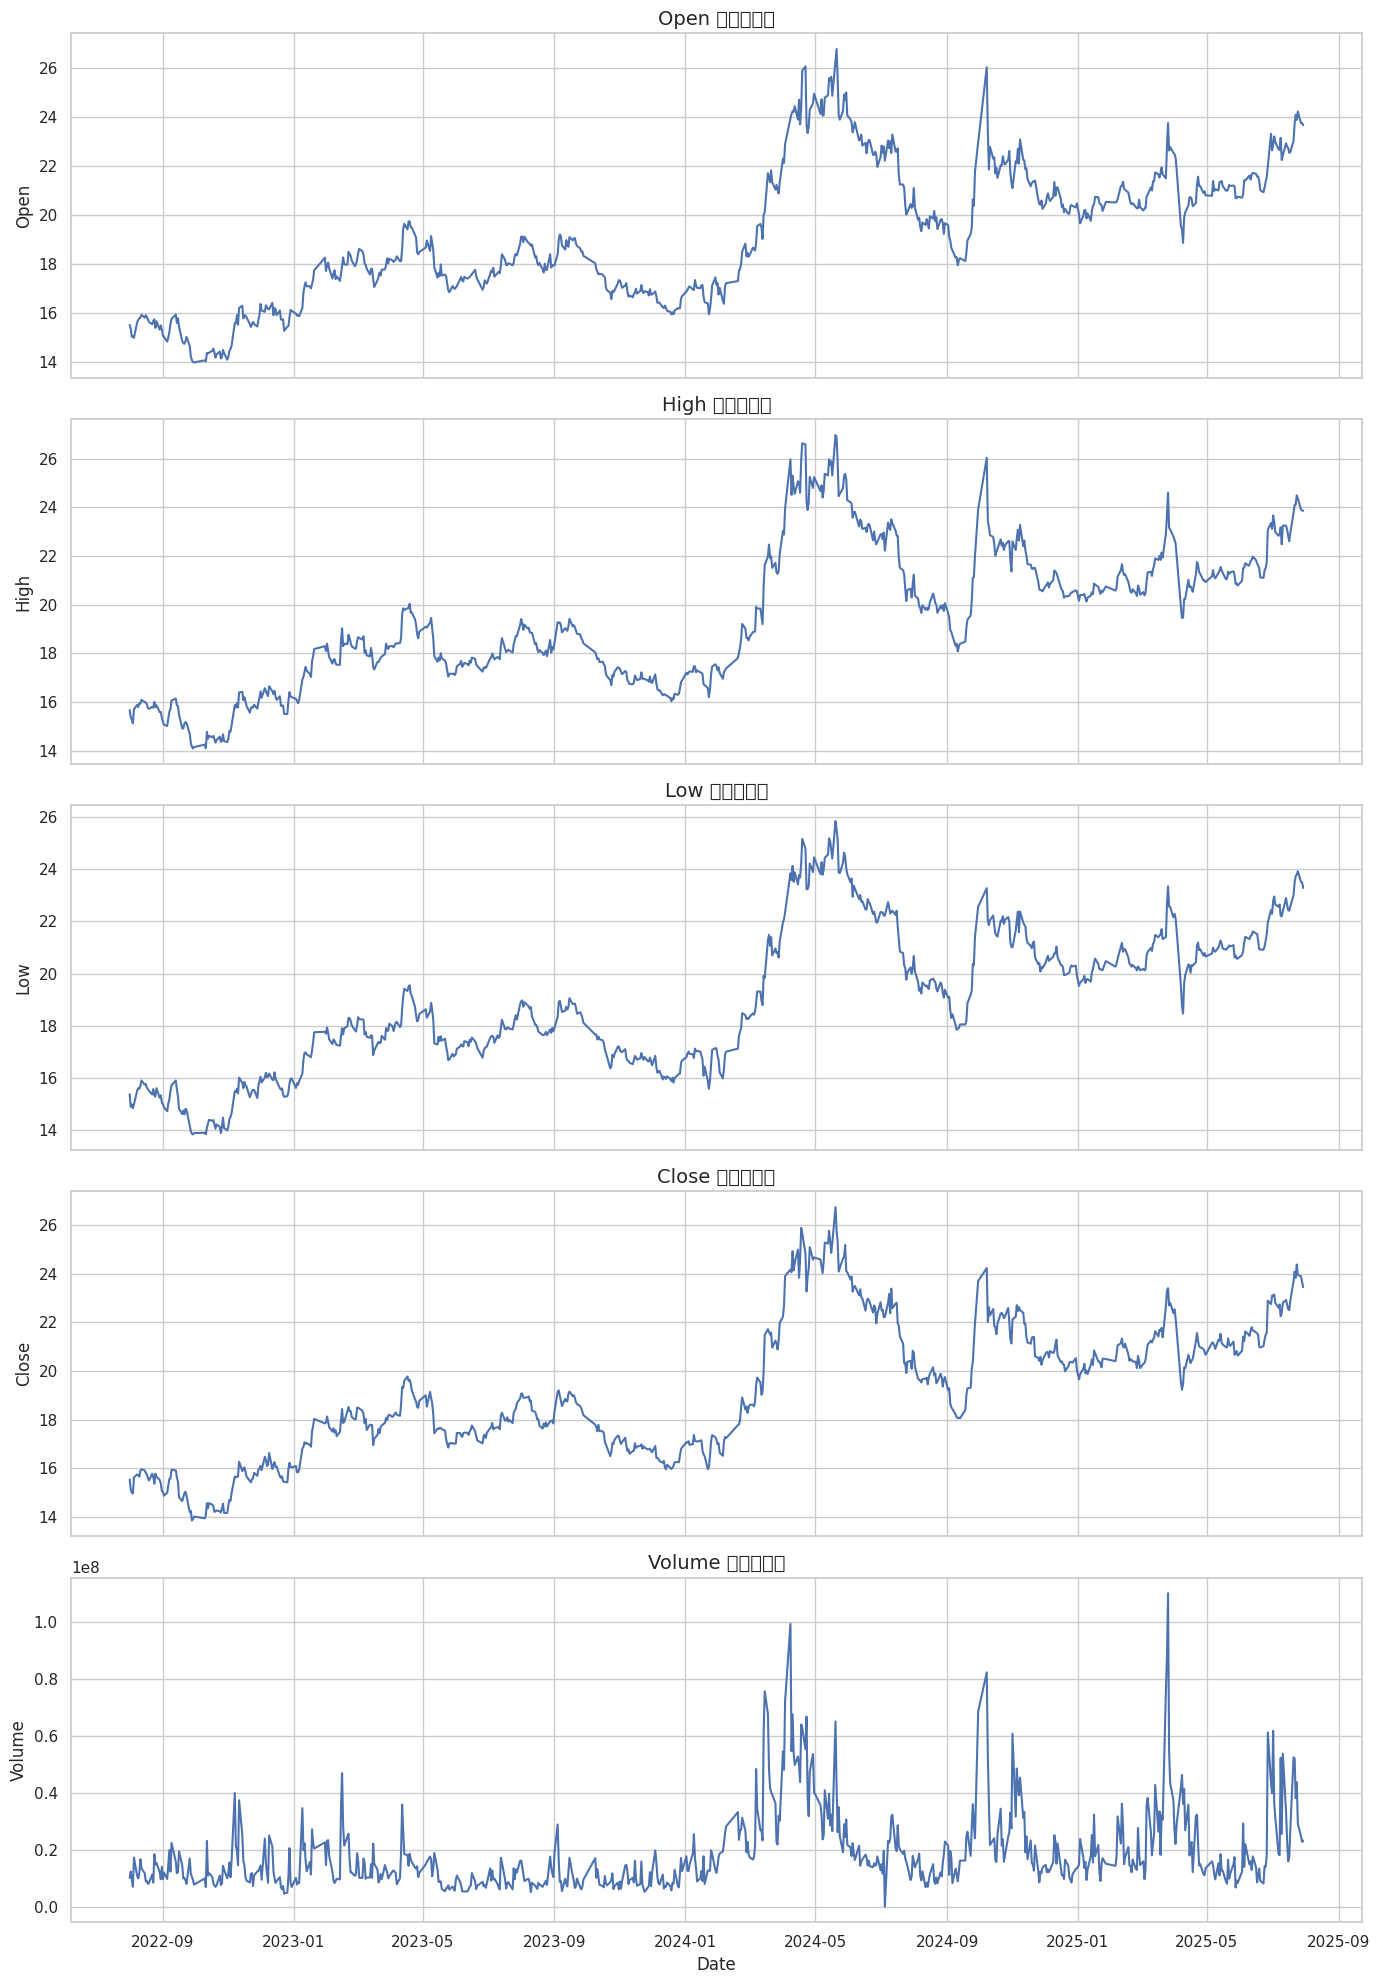

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置风格
sns.set(style="whitegrid")

# 加载清洗后的数据
data = pd.read_csv('cleaned_stock_prices.csv', parse_dates=['Date'])

# 设置日期为索引
data.set_index('Date', inplace=True)

# 创建子图
features = ['Open', 'High', 'Low', 'Close', 'Volume']
fig, axes = plt.subplots(len(features), 1, figsize=(14, 20), sharex=True)

# 绘制每个特征的折线图
for i, feature in enumerate(features):
    sns.lineplot(ax=axes[i], data=data, x=data.index, y=feature)
    axes[i].set_title(f'{feature} 随时间变化', fontsize=14)
    axes[i].set_ylabel(feature)
    axes[i].grid(True)

plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30424 (\N{CJK UNIFIED IDEOGRAPH-76D8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  fig.canvas

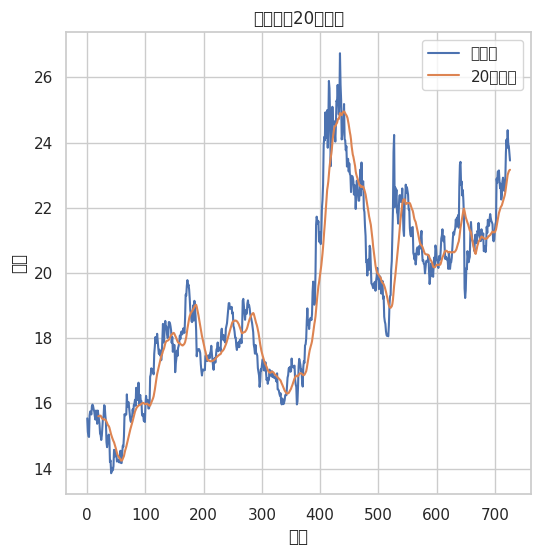

In [ ]:
# 计算滚动平均
data['Close_MA20'] = data['Close'].rolling(window=20).mean()

# 绘制收盘价和均线
plt.figure(figsize=(6, 6))
sns.lineplot(data=data, x=data.index, y='Close', label='收盘价')
sns.lineplot(data=data, x=data.index, y='Close_MA20', label='20日均线')
plt.title('收盘价与20日均线')
plt.xlabel('日期')
plt.ylabel('价格')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
#代码片段是一个完整的流程，用于训练和预测股票价格。它包括数据加载、预处理、模型构建、训练、以及未来价格的预测。下面我将对这段代码进行详细的解释，并确保每一步都清晰明了。
# 代码解释
# 1. 导入库
# python
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
# 这些库用于数据处理、模型构建、训练和可视化。

In [ ]:
# 3. 创建数据集
def create_dataset(dataset, time_step=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - 1):
        a = dataset[i:(i + time_step), :]          # 取过去 time_step 天的数据作为输入
        dataX.append(a)
        dataY.append(dataset[i + time_step, 3])    # 第4列是Close，作为预测目标
    return np.array(dataX), np.array(dataY)

time_step = 50
X, y = create_dataset(scaled_data, time_step)

# create_dataset 函数将时间序列数据转换为监督学习问题所需的输入和输出。
# time_step 设置为 50，意味着使用前 50 天的数据来预测第 51 天的收盘价。

In [ ]:
# 4. 划分训练集和测试集

train_size = int(len(X) * 0.8)
test_size = len(X) - train_size
X_train, X_test = X[0:train_size], X[train_size:len(X)]
y_train, y_test = y[0:train_size], y[train_size:len(y)]
# 将数据集划分为训练集和测试集，比例为 80:20。

In [ ]:
# 5. 构建模型
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout

# 构建模型
model = Sequential()

# 卷积层：提取局部时间特征
model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(time_step, 5)))

# 池化层：降低维度，增强特征鲁棒性
model.add(MaxPooling1D(pool_size=2))

# 第一层 LSTM：捕捉时间序列的长期依赖关系
model.add(LSTM(50, return_sequences=True))

# 第二层 LSTM：输出最终序列表示
model.add(LSTM(50))

# Dropout：防止过拟合
model.add(Dropout(0.5))

# 输出层：预测一个数值（收盘价）
model.add(Dense(1))

# 编译模型
model.compile(optimizer='adam', loss='mean_squared_error')

# 构建一个包含 1D 卷积层、最大池化层、两个 LSTM 层和一个 Dropout 层的序列模型。
# 使用 adam 优化器和均方误差损失函数编译模型。

In [ ]:
# 6. 设置回调并训练模型
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True)

model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=64, verbose=1, callbacks=[early_stopping, model_checkpoint])

model.load_weights('best_model.h5')
# 使用 EarlyStopping 提前停止训练，防止过拟合。
# 使用 ModelCheckpoint 保存最佳模型。
# 训练模型并加载最佳权重。

Epoch 1/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1795

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.1555 - val_loss: 0.0145
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0227 - val_loss: 0.0311
Epoch 3/100
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0164 

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0161 - val_loss: 0.0049
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0140 - val_loss: 0.0146
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0145 - val_loss: 0.0052
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0113 - val_loss: 0.0110
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0106 - val_loss: 0.0058
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0110 - val_loss: 0.0107
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0098 - val_loss: 0.0073
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0100 - val_loss: 0.0075
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0090 - val_loss: 0.0094
Epoch 12/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0084 - val_loss: 0.0088
Epoch 13/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0086 - val_loss: 0.0079


In [ ]:
# 7. 预测和反标准化
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

train_predict = scaler.inverse_transform(np.concatenate((train_predict, np.zeros((train_predict.shape[0], 4))), axis=1))[:, 0]
test_predict = scaler.inverse_transform(np.concatenate((test_predict, np.zeros((test_predict.shape[0], 4))), axis=1))[:, 0]
y_train = scaler.inverse_transform(np.concatenate((y_train.reshape(-1, 1), np.zeros((y_train.shape[0], 4))), axis=1))[:, 0]
y_test = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((y_test.shape[0], 4))), axis=1))[:, 0]
# 预测训练集和测试集的价格。
# 使用 scaler.inverse_transform 将预测结果反标准化。

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


Train Score: 1.15 RMSE
Test Score: 0.90 RMSE


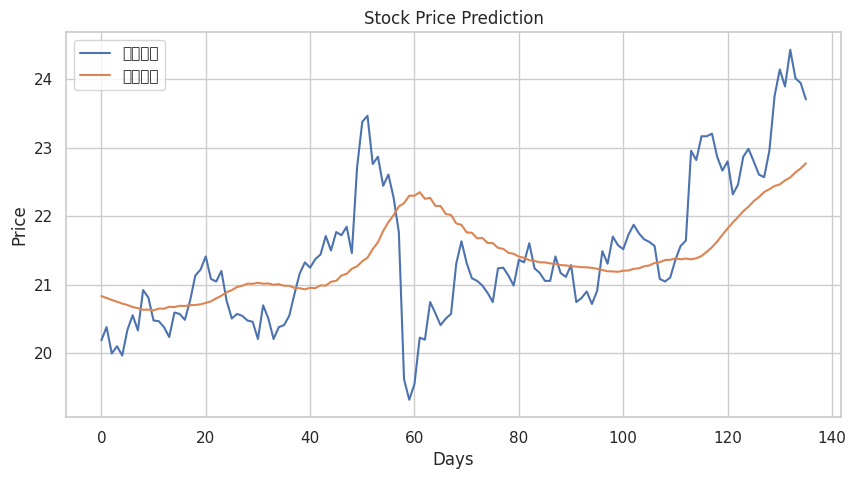

In [ ]:
# 8. 计算均方误差并可视化结果
train_score = np.sqrt(np.mean((train_predict - y_train) ** 2))
test_score = np.sqrt(np.mean((test_predict - y_test) ** 2))
print(f'Train Score: {train_score:.2f} RMSE')
print(f'Test Score: {test_score:.2f} RMSE')

plt.figure(figsize=(10, 5))
plt.plot(y_test, label='真实数据')
plt.plot(test_predict, label='预测数据')
plt.xlabel('Days')
plt.ylabel('Price')
plt.title('Stock Price Prediction')
plt.legend()
plt.show()
# 计算并打印训练和测试集的均方根误差（RMSE）。
# 使用 matplotlib 可视化真实价格和预测价格。

In [ ]:
print("scaler expects", scaler.n_features_in_, "features")


scaler expects 5 features


In [ ]:
# 9. 预测未来10天的价格
data = pd.read_csv('cleaned_stock_prices.csv')
data = data[['Open', 'High', 'Low', 'Close', 'Volume']]

scaled_data = scaler.transform(data)

input_data = scaled_data[-time_step:]
input_data = input_data.reshape(1, time_step, 5)

future_predictions = []

for _ in range(10):
    next_pred = model.predict(input_data)
    future_predictions.append(next_pred[0, 0])

    # Reshape next_pred and add dummy values for other features
    next_pred_reshaped = np.concatenate((next_pred.reshape(1, 1, 1), np.zeros((1, 1, 4))), axis=2)

    new_input = np.append(input_data[:, 1:, :], next_pred_reshaped, axis=1)
    input_data = new_input

# Prepare future_predictions for inverse transform by adding dummy features
future_predictions_with_dummies = np.concatenate((np.array(future_predictions).reshape(-1, 1), np.zeros((len(future_predictions), 4))), axis=1)

future_predictions = scaler.inverse_transform(future_predictions_with_dummies)[:, 0]

for i, price in enumerate(future_predictions, start=1):
    print(f'Day {i} predicted price: {price:.2f}')
# 加载最近的历史数据并标准化。
# 使用模型预测未来 10 天的价格。
# 每次预测后，将预测值添加到输入数据中，以预测下一天的价格。
# 反标准化预测结果并打印。

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Day 1 predicted price: 22.89
Day 2 predicted price: 22.93
Day 3 predicted price: 22.94
Day 4 predicted price: 22.80
Day 5 predicted price: 22.60
Day 6 predicted price: 22.38
Day 7 predicted price: 22.08
Day 8 predicted price: 21.82
Day 9 predicted price: 21.47
Day 10 predicted price: 21.20


/tmp/ipython-input-731454414.py:19: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-731454414.py:19: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-731454414.py:19: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-731454414.py:19: UserWarning: Glyph 30424 (\N{CJK UNIFIED IDEOGRAPH-76D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-731454414.py:19: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-731454414.py:19: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-731454414.py:19: UserWarning: Glyph 26469 (\N{CJK UNIFIED IDEOGRAPH-6765}) missing from

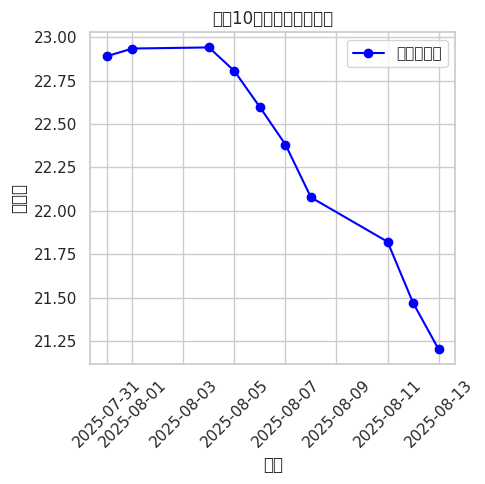

In [ ]:
import matplotlib.pyplot as plt

# 读取原始日期列（假设列名为 'Date'）
data = pd.read_csv('cleaned_stock_prices.csv', parse_dates=['Date'])
last_date = data['Date'].iloc[-1]

# 创建未来10个交易日
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=10, freq='B')

plt.figure(figsize=(5, 5))
plt.plot(future_dates, future_predictions, marker='o', linestyle='-', color='blue', label='预测收盘价')

plt.title('未来10天预测收盘价走势')
plt.xlabel('日期')
plt.ylabel('收盘价')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
